C:\Users\OMEN\AppData\Local\Temp\ipykernel_17696\811276563.py:78: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_tw_f = df_tw[df_tw["text"].str.contains(KEYWORDS_REGEX, na=False)].copy()
C:\Users\OMEN\AppData\Local\Temp\ipykernel_17696\811276563.py:84: FutureWarning: Parsed string "Mon Apr 06 23:02:55 PDT 2009" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df_tw_f["year"] = pd.to_datetime(df_tw_f["date"], errors="coerce").dt.year


Filtered tweets: 1903


Filtered news rows: 2358
Saved yearly sentiment proportions → yearly_sentiment_combined.csv


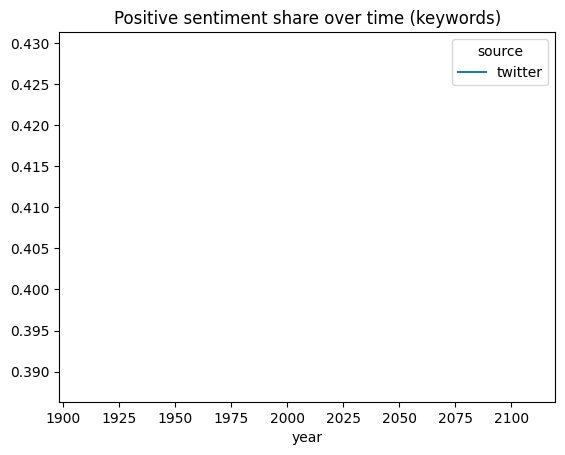

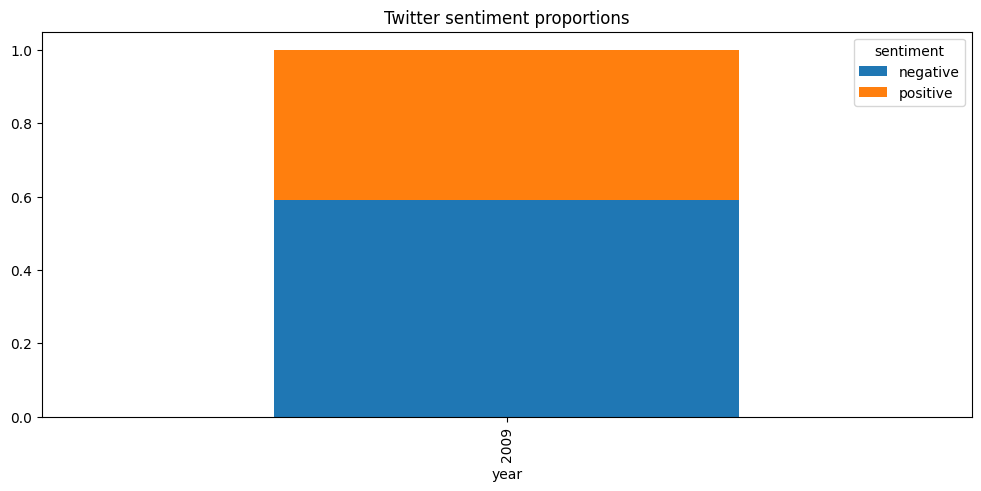

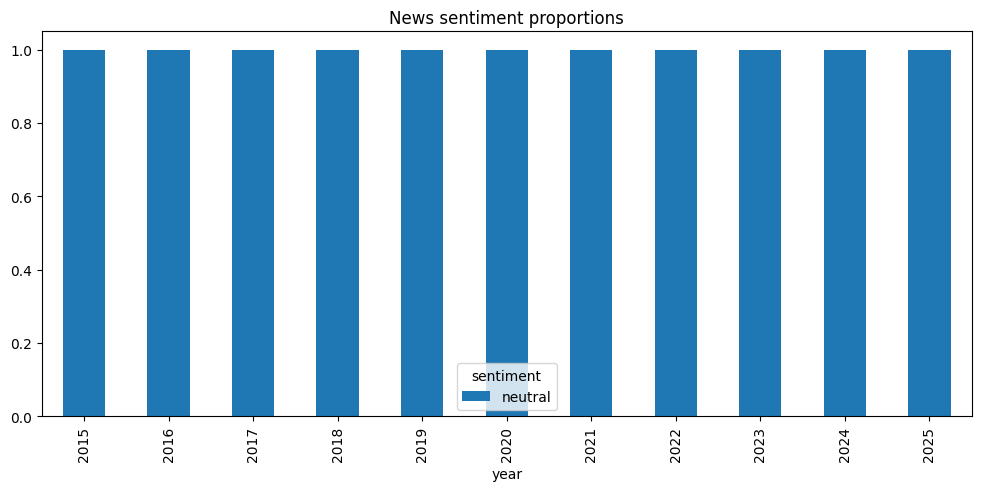

In [4]:
# ===========================================
# 2009–2025 Sentiment Timeline (Local)
# ===========================================

# Goal:
#  - Tweets (2009–2016) → Sentiment140 (pre-labelled)
#  - News (2015–2025)  → GDELT GKG V2Tone sentiment (sampled for speed)
# Outputs:
#  - Yearly sentiment proportions
#  - CSVs and plots
# ===========================================

# 0) Install deps
#!pip install pandas matplotlib tqdm requests pyarrow chardet

# 1) Imports
import os, io, re, csv, time, zipfile
from datetime import datetime, timedelta, timezone
import requests
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import sys, csv

# Bump the per-field limit (some GDELT fields can be huge)
# Try max, and if the platform refuses, step down.
limit = sys.maxsize
while True:
    try:
        csv.field_size_limit(limit)
        break
    except OverflowError:
        limit = int(limit / 10)

# -------------------------------------------
# Parameters
# -------------------------------------------
KEYWORDS = [
    r"data\s?cent(er|re)s?",
    r"\bserver(s)?\b",
    r"\bcloud\b",
    r"artificial intelligence",
    r"\bAI\b",
]
KEYWORDS_REGEX = re.compile("|".join(KEYWORDS), flags=re.IGNORECASE)

# Tweet coverage (2009–2016)
TWEET_MIN_YEAR = 2009
TWEET_MAX_YEAR = 2016

# News coverage (2015–2025, sampled)
GDELT_START = "2015-02-01"
GDELT_END   = datetime.utcnow().strftime("%Y-%m-%d")

SAMPLE_ONE_DAY_PER_MONTH = True
SAMPLED_DAY_OF_MONTH = 1
SAMPLED_HOURS = [0, 6, 12, 18]

# Outputs
OUT_CSV_TWEETS = "sentiment140_filtered.csv"
OUT_CSV_GDELT  = "gdelt_sampled_filtered.csv"
OUT_CSV_YEARLY = "yearly_sentiment_combined.csv"

# -------------------------------------------
# Part A — Tweets (Sentiment140)
# -------------------------------------------
url = "http://cs.stanford.edu/people/alecmgo/trainingandtestdata.zip"
resp = requests.get(url); resp.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
    with zf.open("training.1600000.processed.noemoticon.csv") as f:
        df_tw = pd.read_csv(f, header=None, encoding="latin-1")

df_tw.columns = ["target","ids","date","flag","user","text"]
label_map = {0:"negative", 2:"neutral", 4:"positive"}
df_tw["sentiment"] = df_tw["target"].map(label_map)

df_tw_f = df_tw[df_tw["text"].str.contains(KEYWORDS_REGEX, na=False)].copy()
# Ensure year is numeric and drop NaNs
# Make sure the date column exists
assert "date" in df_tw_f.columns, f"Expected 'date' in columns, got: {df_tw_f.columns.tolist()}"

# Parse year from strings like "Mon Apr 06 22:19:45 PDT 2009"
df_tw_f["year"] = pd.to_datetime(df_tw_f["date"], errors="coerce").dt.year

# Now coerce to numeric and filter the desired window
df_tw_f["year"] = pd.to_numeric(df_tw_f["year"], errors="coerce")
df_tw_f = df_tw_f.dropna(subset=["year"]).copy()
df_tw_f["year"] = df_tw_f["year"].astype(int)
df_tw_f = df_tw_f[(df_tw_f["year"] >= TWEET_MIN_YEAR) & (df_tw_f["year"] <= TWEET_MAX_YEAR)]
df_tw_f.to_csv(OUT_CSV_TWEETS, index=False)
print("Filtered tweets:", len(df_tw_f))

tw_year = (
    df_tw_f.groupby("year")["sentiment"]
           .value_counts(normalize=True)
           .rename("prop")
           .reset_index()
)
tw_year["source"] = "twitter"


# -------------------------------------------
# Part B — News (GDELT GKG)
# -------------------------------------------
BASE = "http://data.gdeltproject.org/gdeltv2/{stamp}.gkg.csv.zip"
TONE_REGEX = re.compile(r"^-?\d+(?:\.\d+)?(?:,-?\d+(?:\.\d+)?){5}$")
THEME_TOKENS = set([
    "ARTIFICIAL_INTELLIGENCE","MACHINE_LEARNING","CLOUD_COMPUTING",
    "DATA_CENTER","DATA_CENTERS","DATACENTER","SERVER_FARMS","SERVER",
    "COLOCATION","HYPERSCALE","GPU","NVIDIA","DATA_SOVEREIGNTY"
])

def ts_stamp(dt): return dt.strftime("%Y%m%d%H%M%S")

def fetch_zip(url, timeout=30):
    try:
        r = requests.get(url, timeout=timeout)
        if r.status_code==200: return r.content
    except: pass
    return b""

def parse_zip_csv(blob):
    if not blob: return []
    out=[]
    with zipfile.ZipFile(io.BytesIO(blob)) as zf:
        name=[n for n in zf.namelist() if n.endswith(".csv")][0]
        with zf.open(name) as fh:
            text=io.TextIOWrapper(fh,encoding="utf-8",errors="replace")
            reader=csv.reader(text, delimiter="\t")
            for row in reader:
                if row: out.append(row)
    return out

def extract_fields(row):
    out={"DATE":None,"SourceCommonName":None,"DocumentIdentifier":None,"V2ToneStr":None}
    if len(row)>1 and re.fullmatch(r"\d{14}", row[1] or ""): out["DATE"]=row[1]
    if len(row)>3: out["SourceCommonName"]=row[3]
    for idx in (4,5,6,7):
        if len(row)>idx and ("http" in str(row[idx])):
            out["DocumentIdentifier"]=row[idx]; break
    for cell in row:
        if cell and TONE_REGEX.match(cell): out["V2ToneStr"]=cell; break
    return out

def tone_to_bucket(t):
    if pd.isna(t): return "neutral"
    if t>1.0: return "positive"
    if t<-1.0: return "negative"
    return "neutral"

gd_start=datetime.strptime(GDELT_START,"%Y-%m-%d").replace(tzinfo=timezone.utc)
gd_end=datetime.strptime(GDELT_END,"%Y-%m-%d").replace(tzinfo=timezone.utc)

stamps=[]
cur=datetime(gd_start.year,gd_start.month,1,tzinfo=timezone.utc)
while cur<=gd_end:
    day=datetime(cur.year,cur.month,min(SAMPLED_DAY_OF_MONTH,28),tzinfo=timezone.utc)
    for h in SAMPLED_HOURS:
        stamps.append(day.replace(hour=h))
    cur=(datetime(cur.year+1,1,1,tzinfo=timezone.utc) if cur.month==12 
         else datetime(cur.year,cur.month+1,1,tzinfo=timezone.utc))

rows=[]
for dt in tqdm(stamps, desc="Downloading GDELT"):
    blob=fetch_zip(BASE.format(stamp=ts_stamp(dt)))
    for row in parse_zip_csv(blob):
        f=extract_fields(row)
        text=" ".join([str(f.get("SourceCommonName") or ""), str(f.get("DocumentIdentifier") or "")])
        if not KEYWORDS_REGEX.search(text): continue
        tone=None
        if f.get("V2ToneStr"):
            try: tone=float(f["V2ToneStr"].split(",")[0])
            except: pass
        if not f.get("DATE"): continue
        year=int(f["DATE"][:4])
        rows.append({"year":year,"tone":tone,"bucket":tone_to_bucket(tone)})

df_gd=pd.DataFrame(rows)
df_gd.to_csv(OUT_CSV_GDELT,index=False)
print("Filtered news rows:", len(df_gd))

# bucket column is your sentiment label for news
gd_year = (
    df_gd.dropna(subset=["year"])
         .groupby("year")["bucket"]
         .value_counts(normalize=True)
         .rename("prop")
         .reset_index()
         .rename(columns={"bucket": "sentiment"})
)
gd_year["source"] = "news"


# -------------------------------------------
# Combine + Save
# -------------------------------------------
yearly = pd.concat([tw_year, gd_year], ignore_index=True, sort=False)
yearly.to_csv(OUT_CSV_YEARLY, index=False)


print("Saved yearly sentiment proportions →", OUT_CSV_YEARLY)

# -------------------------------------------
# Plot
# -------------------------------------------
pos=yearly[yearly["sentiment"]=="positive"].pivot(index="year",columns="source",values="prop")
pos.plot(title="Positive sentiment share over time (keywords)")
plt.show()

def plot_stacked(src):
    d=yearly[yearly["source"]==src].pivot(index="year",columns="sentiment",values="prop").fillna(0)
    d=d[[c for c in ["negative","neutral","positive"] if c in d.columns]]
    d.plot(kind="bar", stacked=True, figsize=(12,5), title=f"{src.capitalize()} sentiment proportions")
    plt.show()

plot_stacked("twitter")
plot_stacked("news")


GDELT rows after tone drop: 0
GDELT yearly counts:
 Series([], Name: count, dtype: Int64)
GDELT mean tone by year (head):
 Empty DataFrame
Columns: [year, avg_tone]
Index: []


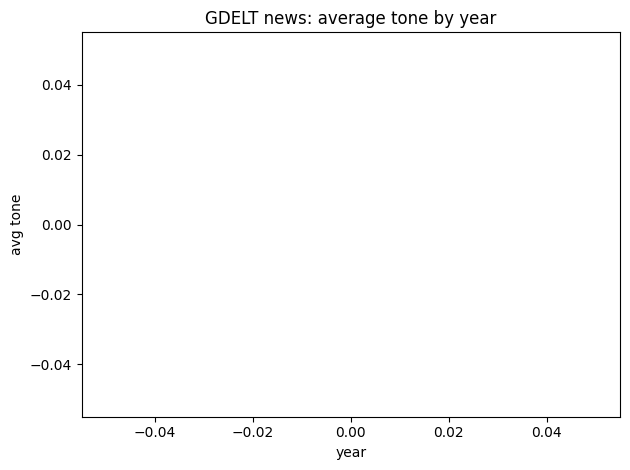

Rows after cleaning: 0
Years seen: <IntegerArray>
[]
Length: 0, dtype: Int64
gd_mean is empty (no tones after filtering).
gd_year is empty (no rows to aggregate).


KeyError: 'sentiment'

In [ ]:
# Ensure tone is numeric and drop NaNs
df_gd["tone"] = pd.to_numeric(df_gd["tone"], errors="coerce")
df_gd = df_gd.dropna(subset=["tone"]).copy()
df_gd["year"] = pd.to_numeric(df_gd["year"], errors="coerce").astype("Int64")

# 1) Mean tone by year (more informative than coarse buckets)
gd_mean = (
    df_gd.groupby("year")["tone"]
         .mean()
         .reset_index(name="avg_tone")
         .dropna(subset=["year"])
         .sort_values("year")
)

# 2) Softer bucket thresholds (±0.2 works well for GDELT)
def tone_to_bucket_soft(t):
    if t >= 0.2:  return "positive"
    if t <= -0.2: return "negative"
    return "neutral"

df_gd["sentiment"] = df_gd["tone"].apply(tone_to_bucket_soft)

gd_year = (
    df_gd.groupby(["year","sentiment"]).size()
         .groupby(level=0).apply(lambda s: s/s.sum())
         .rename("prop")
         .reset_index()
         .sort_values("year")
)
gd_year["source"] = "news"

# Quick sanity checks
print("GDELT rows after tone drop:", len(df_gd))
print("GDELT yearly counts:\n", df_gd["year"].value_counts().sort_index())
print("GDELT mean tone by year (head):\n", gd_mean.head())

# Plot mean tone (line)
import matplotlib.pyplot as plt
plt.figure()
plt.plot(gd_mean["year"], gd_mean["avg_tone"])
plt.title("GDELT news: average tone by year")
plt.xlabel("year"); plt.ylabel("avg tone")
plt.tight_layout(); plt.show()

# Plot soft-bucket proportions (stacked bar)import pandas as pd
import matplotlib.pyplot as plt

# --- Safety checks & coercions ---
assert 'df_gd' in globals(), "df_gd is not defined. Run the GDELT download cell first."

df_gd = df_gd.copy()
for col in ['year', 'tone']:
    if col not in df_gd.columns:
        raise KeyError(f"Expected column '{col}' in df_gd, got: {df_gd.columns.tolist()}")

df_gd['tone'] = pd.to_numeric(df_gd['tone'], errors='coerce')
df_gd['year'] = pd.to_numeric(df_gd['year'], errors='coerce').astype('Int64')
df_gd = df_gd.dropna(subset=['tone', 'year']).copy()

# --- Softer sentiment buckets for GDELT tone ---
def tone_to_bucket_soft(t):
    if pd.isna(t): return 'neutral'
    if t >= 0.2:   return 'positive'
    if t <= -0.2:  return 'negative'
    return 'neutral'

df_gd['sentiment'] = df_gd['tone'].apply(tone_to_bucket_soft)

# --- Yearly mean tone (line) ---
gd_mean = (df_gd.groupby('year')['tone']
                 .mean()
                 .reset_index(name='avg_tone')
                 .sort_values('year'))

# --- Yearly proportions by sentiment (stacked bars) ---
gd_year = (df_gd.groupby(['year','sentiment']).size()
                 .groupby(level=0).apply(lambda s: s/s.sum())
                 .rename('prop')
                 .reset_index()
                 .sort_values('year'))
gd_year['source'] = 'news'
import pandas as pd
import matplotlib.pyplot as plt

# --- Safety checks & coercions ---
assert 'df_gd' in globals(), "df_gd is not defined. Run the GDELT download cell first."

df_gd = df_gd.copy()
for col in ['year', 'tone']:
    if col not in df_gd.columns:
        raise KeyError(f"Expected column '{col}' in df_gd, got: {df_gd.columns.tolist()}")

df_gd['tone'] = pd.to_numeric(df_gd['tone'], errors='coerce')
df_gd['year'] = pd.to_numeric(df_gd['year'], errors='coerce').astype('Int64')
df_gd = df_gd.dropna(subset=['tone', 'year']).copy()

# --- Softer sentiment buckets for GDELT tone ---
def tone_to_bucket_soft(t):
    if pd.isna(t): return 'neutral'
    if t >= 0.2:   return 'positive'
    if t <= -0.2:  return 'negative'
    return 'neutral'

df_gd['sentiment'] = df_gd['tone'].apply(tone_to_bucket_soft)

# --- Yearly mean tone (line) ---
gd_mean = (df_gd.groupby('year')['tone']
                 .mean()
                 .reset_index(name='avg_tone')
                 .sort_values('year'))

# --- Yearly proportions by sentiment (stacked bars) ---
gd_year = (df_gd.groupby(['year','sentiment']).size()
                 .groupby(level=0).apply(lambda s: s/s.sum())
                 .rename('prop')
                 .reset_index()
                 .sort_values('year'))
gd_year['source'] = 'news'

print("Rows after cleaning:", len(df_gd))
print("Years seen:", df_gd['year'].dropna().unique())

# --- Plots (guard for empties) ---
if not gd_mean.empty:
if not gd_mean.empty:
    plt.figure()
    plt.plot(gd_mean['year'], gd_mean['avg_tone'])
    plt.title('GDELT news: average tone by year')
    plt.xlabel('year'); plt.ylabel('avg tone')
    plt.tight_layout(); plt.show()
else:
    print("gd_mean is empty (no tones after filtering).")

if not gd_year.empty:
    d = gd_year.pivot_table(index='year', columns='sentiment', values='prop', fill_value=0)
    d = d.reindex(columns=[c for c in ['negative','neutral','positive'] if c in d.columns])
    d.plot(kind='bar', stacked=True, figsize=(12,5), title='GDELT news sentiment proportions by year')
    plt.tight_layout(); plt.show()
else:
    print("gd_year is empty (no rows to aggregate).")

print("Rows after cleaning:", len(df_gd))
print("Years seen:", df_gd['year'].dropna().unique())

# --- Plots (guard for empties) ---
if not gd_mean.empty:
    plt.figure()
    plt.plot(gd_mean['year'], gd_mean['avg_tone'])
    plt.title('GDELT news: average tone by year')
    plt.xlabel('year'); plt.ylabel('avg tone')
    plt.tight_layout(); plt.show()
else:
    print("gd_mean is empty (no tones after filtering).")

if not gd_year.empty:
    d = gd_year.pivot_table(index='year', columns='sentiment', values='prop', fill_value=0)
    d = d.reindex(columns=[c for c in ['negative','neutral','positive'] if c in d.columns])
    d.plot(kind='bar', stacked=True, figsize=(12,5), title='GDELT news sentiment proportions by year')
    plt.tight_layout(); plt.show()
else:
    print("gd_year is empty (no rows to aggregate).")

d = gd_year.pivot(index="year", columns="sentiment", values="prop").fillna(0)
d = d[[c for c in ["negative","neutral","positive"] if c in d.columns]]
d.plot(kind="bar", stacked=True, figsize=(12,5), title="GDELT news sentiment proportions by year")
plt.tight_layout(); plt.show()
